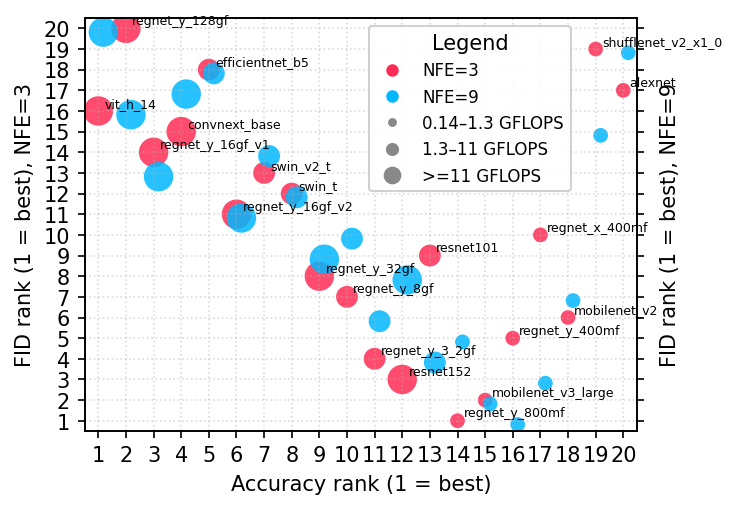

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (name, Acc@5, GFLOPS, FID@3)
raw = [
    ("vit_h_14",98.694,1016.72,10.71), ("regnet_y_128gf",97.844,127.52,12.99),
    ("regnet_y_16gf_v1",97.244,15.91,9.97), ("convnext_base",96.870,15.36,10.28),
    ("efficientnet_b5",96.628,10.27,11.53), ("regnet_y_16gf_v2",96.328,15.91,9.63),
    ("swin_v2_t",96.132,5.94,9.73), ("swin_t",95.776,4.49,9.65),
    ("regnet_y_32gf",95.340,32.28,9.55), ("regnet_y_8gf",95.048,8.47,9.54),
    ("regnet_y_3_2gf",94.576,3.18,9.50), ("resnet152",94.046,11.51,9.49),
    ("resnet101",93.546,7.80,9.59), ("regnet_y_800mf",93.136,0.83,9.40),
    ("mobilenet_v3_large",92.566,0.22,9.44), ("regnet_y_400mf",91.716,0.40,9.50),
    ("regnet_x_400mf",90.950,0.41,9.60), ("mobilenet_v2",90.286,0.30,9.52),
    ("shufflenet_v2_x1_0",88.316,0.14,11.57), ("alexnet",79.066,0.71,11.20),
]

fid9 = np.array([
    6.72, 5.61, 5.32, 5.78, 6.01, 5.21, 5.34, 5.29, 5.04, 5.10,
    5.01, 5.03, 4.98, 4.99, 4.87, 4.87, 4.93, 5.03, 5.51, 6.22
])

names, acc5, gflops, fid3 = map(np.array, zip(*raw))
N = len(names)

# ranks (1 = best)
acc_rank = np.empty(N, int); acc_rank[np.argsort(-acc5)] = np.arange(1, N+1)
r3 = np.empty(N, int);       r3[np.argsort(fid3)]        = np.arange(1, N+1)
r9 = np.empty(N, int);       r9[np.argsort(fid9)]        = np.arange(1, N+1)

# marker sizes from GFLOPS (3 log-quantile bins)
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
bin_idx = np.clip(np.digitize(gflops, edges, right=False) - 1, 0, 2)
svals = sizes[bin_idx]

fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=150)

# 빨간 점: NFE=3 (그대로)
s1 = ax.scatter(
    acc_rank, r3,
    s=svals,
    c="#FF2D55",
    alpha=.85,
    edgecolors="none",
    label="NFE=3",
)

# 파란 점: NFE=9 (살짝 우상향으로 offset)
offset_x, offset_y = 0.18, 0.18  # 튜닝해도 됨
s2 = ax.scatter(
    acc_rank + offset_x,   # 오른쪽으로 살짝
    r9        - offset_y,  # 위쪽으로 살짝 (rank 값은 시각적으로만 이동)
    s=svals,
    c="#00B8FF",
    alpha=.85,
    edgecolors="none",
    label="NFE=9",
)

# FID@3 포인트에만 이름 라벨
for x, y, t in zip(acc_rank, r3, names):
    ax.annotate(
        t, (x, y),
        xytext=(3, 2),
        textcoords="offset points",
        fontsize=6,
    )

# rank ticks 1..20
ticks = np.arange(1, N+1)
ax.set_xlim(.5, N + .5)
ax.set_ylim(.5, N + .5)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

# 오른쪽 y축: NFE=9 설명용 라벨
right = ax.twinx()
right.set_ylim(ax.get_ylim())
right.set_yticks(ticks)
right.set_yticklabels([""] * N)
right.set_ylabel("FID rank (1 = best), NFE=9")

ax.set_xlabel("Accuracy rank (1 = best)")
ax.set_ylabel("FID rank (1 = best), NFE=3")
ax.grid(True, ls=":", alpha=.45)

# --- legend: NFE colors + GFLOPS size bins ---
size_handles = []
for i in range(3):
    lo, hi = edges[i], edges[i+1]
    if i < 2:
        lbl = f"{lo:.2g}–{hi:.2g} GFLOPS"
    else:
        lbl = f">={lo:.2g} GFLOPS"
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=(sizes[i]**0.5) * 0.6,
            markerfacecolor="#888",
            markeredgecolor='none',
            label=lbl,
        )
    )

handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#FF2D55", markeredgecolor='none', label="NFE=3"),
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#00B8FF", markeredgecolor='none', label="NFE=9"),
] + size_handles

ax.legend(
    handles=handles,
    bbox_to_anchor=(0.5, 0.56),
    framealpha=.9,
    fontsize=8,
    title="Legend",
)

plt.tight_layout()
plt.show()


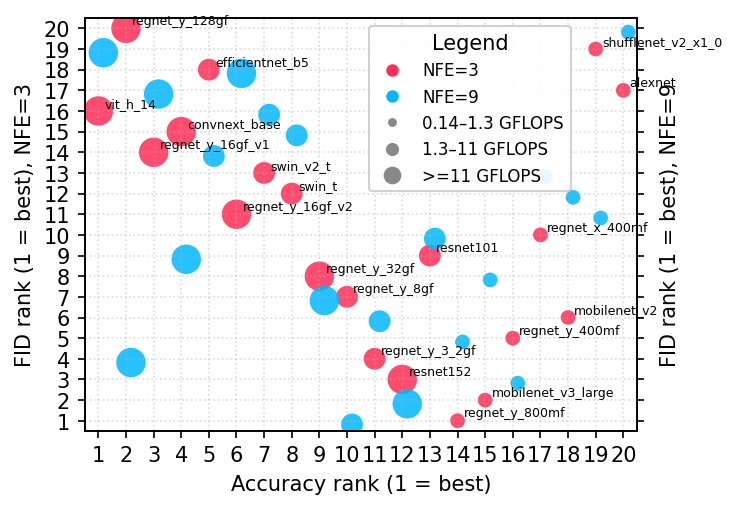

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# raw now stores both FID@3 and FID@9
# (name, Acc@5, GFLOPS, FID@3, FID@9)
raw = [
    ("vit_h_14",            98.694, 1016.72, 10.71, 5.89),
    ("regnet_y_128gf",      97.844,  127.52, 12.99, 3.44),
    ("regnet_y_16gf_v1",    97.244,   15.91,  9.97, 5.25),
    ("convnext_base",       96.870,   15.36, 10.28, 3.98),
    ("efficientnet_b5",     96.628,   10.27, 11.53, 4.85),
    ("regnet_y_16gf_v2",    96.328,   15.91,  9.63, 5.39),
    ("swin_v2_t",           96.132,    5.94,  9.73, 5.10),
    ("swin_t",              95.776,    4.49,  9.65, 5.07),
    ("regnet_y_32gf",       95.340,   32.28,  9.55, 3.76),
    ("regnet_y_8gf",        95.048,    8.47,  9.54, 2.93),
    ("regnet_y_3_2gf",      94.576,    3.18,  9.50, 3.68),
    ("resnet152",           94.046,   11.51,  9.49, 3.07),
    ("resnet101",           93.546,    7.80,  9.59, 4.05),
    ("regnet_y_800mf",      93.136,    0.83,  9.40, 3.45),
    ("mobilenet_v3_large",  92.566,    0.22,  9.44, 3.90),
    ("regnet_y_400mf",      91.716,    0.40,  9.50, 3.10),
    ("regnet_x_400mf",      90.950,    0.41,  9.60, 4.84),
    ("mobilenet_v2",        90.286,    0.30,  9.52, 4.20),
    ("shufflenet_v2_x1_0",  88.316,    0.14, 11.57, 4.13),
    ("alexnet",             79.066,    0.71, 11.20, 6.29),
]

names, acc5, gflops, fid3, fid9 = map(np.array, zip(*raw))
N = len(names)

# ranks (1 = best)
acc_rank = np.empty(N, int); acc_rank[np.argsort(-acc5)] = np.arange(1, N+1)
r3 = np.empty(N, int);       r3[np.argsort(fid3)]        = np.arange(1, N+1)
r9 = np.empty(N, int);       r9[np.argsort(fid9)]        = np.arange(1, N+1)

# marker sizes from GFLOPS (3 log-quantile bins)
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
bin_idx = np.clip(np.digitize(gflops, edges, right=False) - 1, 0, 2)
svals = sizes[bin_idx]

fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=150)

# NFE=3
ax.scatter(
    acc_rank, r3,
    s=svals, c="#FF2D55", alpha=.85, edgecolors="none", label="NFE=3"
)

# NFE=9 (visual offset)
offset_x, offset_y = 0.18, 0.18
ax.scatter(
    acc_rank + offset_x, r9 - offset_y,
    s=svals, c="#00B8FF", alpha=.85, edgecolors="none", label="NFE=9"
)

# label only NFE=3 points
for x, y, t in zip(acc_rank, r3, names):
    ax.annotate(t, (x, y), xytext=(3, 2), textcoords="offset points", fontsize=6)

ticks = np.arange(1, N+1)
ax.set_xlim(.5, N + .5)
ax.set_ylim(.5, N + .5)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

right = ax.twinx()
right.set_ylim(ax.get_ylim())
right.set_yticks(ticks)
right.set_yticklabels([""] * N)
right.set_ylabel("FID rank (1 = best), NFE=9")

ax.set_xlabel("Accuracy rank (1 = best)")
ax.set_ylabel("FID rank (1 = best), NFE=3")
ax.grid(True, ls=":", alpha=.45)

# legend: NFE colors + GFLOPS size bins
size_handles = []
for i in range(3):
    lo, hi = edges[i], edges[i+1]
    lbl = f"{lo:.2g}–{hi:.2g} GFLOPS" if i < 2 else f">={lo:.2g} GFLOPS"
    size_handles.append(
        Line2D([0], [0], marker='o', linestyle='',
               markersize=(sizes[i]**0.5) * 0.6,
               markerfacecolor="#888", markeredgecolor='none', label=lbl)
    )

handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#FF2D55", markeredgecolor='none', label="NFE=3"),
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#00B8FF", markeredgecolor='none', label="NFE=9"),
] + size_handles

ax.legend(
    handles=handles,
    bbox_to_anchor=(0.5, 0.56),
    framealpha=.9,
    fontsize=8,
    title="Legend",
)

plt.tight_layout()
plt.show()
